In [2]:
#Imports
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input

from tensorflow.keras.models import Model

In [3]:
#load dataset
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
#explore
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


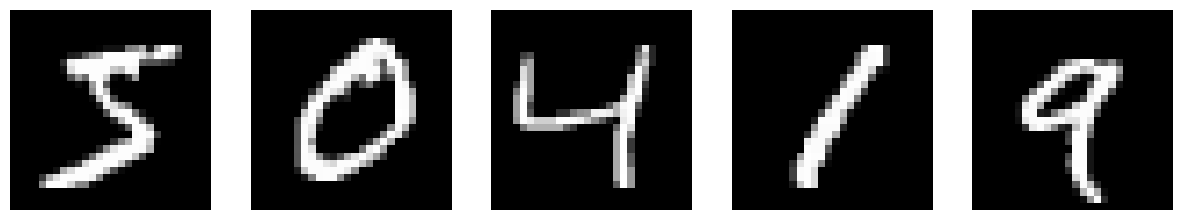

In [5]:
#visualize
fig, axs=plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
  axs[i].imshow(x_train[i], cmap="gray")
  axs[i].axis("off")
plt.show()

In [6]:
#normalize
x_train=x_train.astype("float32")/255.
x_test=x_test.astype("float32")/255.

In [7]:
#reshape
x_train = np.reshape(x_train, (len(x_train),28,28,1))
x_test = np.reshape(x_test,(len(x_test),28,28,1))

In [8]:
#add noise
noise_factor = 0.5

x_train_noisy = x_train + noise_factor*np.random.normal(
loc=0.0,
scale=1.0,
size=x_train.shape)

x_test_noisy = x_test + noise_factor*np.random.normal(
loc=0.0,
scale=1.0,
size=x_test.shape)

In [9]:
#clip values
x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

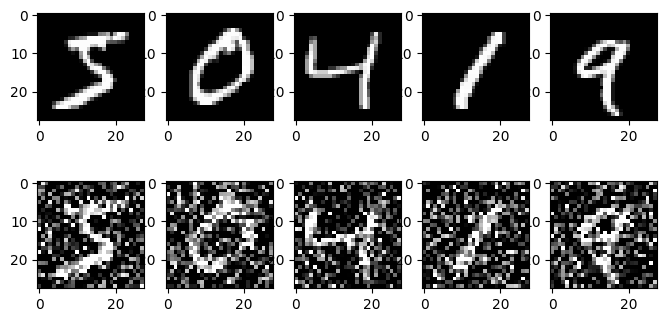

In [10]:
#visualize
plt.figure(figsize=(8,4))

for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28),cmap='gray')

    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(28,28),cmap='gray')

plt.show()

In [11]:
#encoder
input_img = Input(shape=(28,28,1))

x = Conv2D(
32,
(3,3),
activation='relu',
padding='same')(input_img)

x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(
16,
(3,3),
activation='relu',
padding='same')(x)

encoded = MaxPooling2D((2,2),padding='same')(x)

In [12]:
#decoder
x = Conv2D(
16,
(3,3),
activation='relu',
padding='same')(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(
32,
(3,3),
activation='relu',
padding='same')(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(
1,
(3,3),
activation='sigmoid',
padding='same')(x)

In [13]:
#create model
autoencoder = Model(input_img, decoded)

In [14]:
#compile
autoencoder.compile(
optimizer='adam',
loss='binary_crossentropy'
)

In [15]:
#summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#train
history = autoencoder.fit(

x_train_noisy,

x_train,

epochs=10,

batch_size=128,

shuffle=True,

validation_data=(x_test_noisy,x_test)

)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.1861 - val_loss: 0.1231
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1187 - val_loss: 0.1136
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1124 - val_loss: 0.1092
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1092 - val_loss: 0.1070
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1073 - val_loss: 0.1053
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1057 - val_loss: 0.1040
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1046 - val_loss: 0.1030
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1037 - val_loss: 0.1022
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1029 - val_loss: 0.1017
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1024 - val_loss: 0.1010


In [17]:
#predict
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


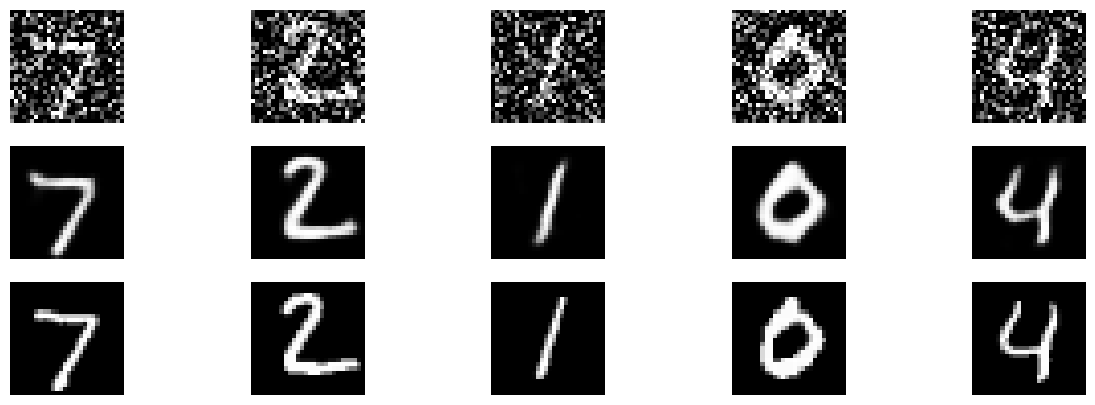

In [18]:
#compare results
n = 5

plt.figure(figsize=(15,5))

for i in range(n):

    # Noisy Image
    plt.subplot(3,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Denoised Image
    plt.subplot(3,n,i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Original Image
    plt.subplot(3,n,i+2*n+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [19]:
#evaluation
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

mse = np.mean((x_test - decoded_imgs) ** 2)
psnr = peak_signal_noise_ratio(
    x_test[0].squeeze(),
    decoded_imgs[0].squeeze(),
    data_range=1.0
)
ssim = structural_similarity(
    x_test[0].squeeze(),
    decoded_imgs[0].squeeze(),
    data_range=1.0
)

print("MSE:", mse)
print("PSNR:", psnr)
print("SSIM:", ssim)

MSE: 0.012614599
PSNR: 21.21627304666906
SSIM: 0.8576692990950994
